# 09 Probabilistic Forecasting & Uncertainty Quantification

Most forecasting models output a single number the **point forecast**. But in the real world, decisions depend on *how uncertain* that forecast is. A retailer stocking 100 units when demand could be anywhere from 50 to 200 faces a very different risk than if demand is tightly concentrated around 100.

**Probabilistic forecasting** replaces the single number with a full distribution (or at least a prediction interval), letting decision-makers reason about risk explicitly.

## Why Probabilistic Forecasting?

| Use-case | What you need |
|---|---|
| Inventory planning | P90 demand to set safety stock |
| Energy dispatch | Full distribution for cost-optimal scheduling |
| Finance | VaR / CVaR requires tail quantiles |
| Medical dosing | Conservative (P95) vs aggressive (P50) threshold |
| SLA budgeting | P99 latency, not mean latency |

### Key concepts

- **Prediction interval** $[l_\alpha, u_\alpha]$: contains the true value with probability $1-\alpha$.
- **Coverage**: $P(y_{t+h} \in [l, u]) \geq 1 - \alpha$.
- **Sharpness**: interval should be as *narrow* as possible subject to coverage.
- **Calibration**: predicted quantile $\tau$ should match empirical frequency $\tau$.

## 1. Quantile Regression

Instead of minimizing squared error (which gives the conditional mean), **quantile regression** minimizes the **pinball loss** (also called the check function) to estimate any conditional quantile $Q_\tau(y|x)$.

$$L_\tau(y, \hat{y}) = (y - \hat{y})\bigl(\tau - \mathbf{1}[y < \hat{y}]\bigr)$$

Expanded:
$$L_\tau(y, \hat{y}) = \begin{cases} \tau \cdot |y - \hat{y}| & \text{if } y \geq \hat{y} \\ (1-\tau) \cdot |y - \hat{y}| & \text{if } y < \hat{y} \end{cases}$$

At $\tau = 0.5$ this reduces to the MAE (median regression). At $\tau = 0.9$ the loss penalises under-prediction 9× more than over-prediction, so the model learns the 90th percentile.

### Quantile Regression Forests (QRF)

A Random Forest variant that, instead of averaging leaf values, **stores all training samples** in each leaf. At prediction time, collect all leaf samples across trees → empirical CDF → read off any quantile. No distributional assumption required.

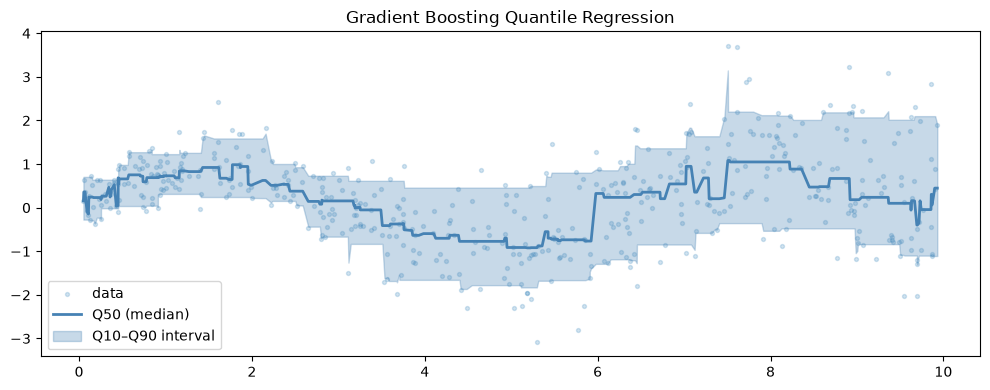

Empirical 80% coverage: 0.794  (target 0.800)
Pinball loss Q90: 0.1292


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(42)

# Synthetic heteroscedastic data
n = 500
X = np.sort(np.random.uniform(0, 10, n)).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.normal(0, 0.3 + 0.1 * X.ravel(), n)

# --- Pinball loss (scratch) ---
def pinball_loss(y_true, y_pred, tau):
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, tau * err, (tau - 1) * err))

# --- Fit quantile regressors at tau = 0.1, 0.5, 0.9 ---
quantiles = [0.1, 0.5, 0.9]
preds = {}
for q in quantiles:
    # GradientBoostingRegressor supports quantile loss natively
    model = GradientBoostingRegressor(
        loss='quantile', alpha=q, n_estimators=200,
        max_depth=3, learning_rate=0.05
    )
    model.fit(X, y)
    preds[q] = model.predict(X)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X, y, alpha=0.2, s=8, label='data')
ax.plot(X, preds[0.5], color='steelblue', lw=2, label='Q50 (median)')
ax.fill_between(X.ravel(), preds[0.1], preds[0.9],
                alpha=0.3, color='steelblue', label='Q10-Q90 interval')
ax.set_title('Gradient Boosting Quantile Regression')
ax.legend()
plt.tight_layout()
plt.show()

# Coverage check
coverage = np.mean((y >= preds[0.1]) & (y <= preds[0.9]))
print(f"Empirical 80% coverage: {coverage:.3f}  (target 0.800)")
print(f"Pinball loss Q90: {pinball_loss(y, preds[0.9], 0.9):.4f}")

## 2. Conformal Prediction for Time Series

**Conformal prediction** provides *distribution-free*, *finite-sample* coverage guarantees. No parametric assumption on residuals.

### Split Conformal (Inductive Conformal Prediction)

1. Split data into **train** $\mathcal{D}_{\text{tr}}$ and **calibration** $\mathcal{D}_{\text{cal}}$.
2. Fit model $\hat{f}$ on $\mathcal{D}_{\text{tr}}$.
3. Compute **conformity scores** on calibration: $s_i = |y_i - \hat{f}(x_i)|$.
4. Let $\hat{q}$ be the $\lceil(1-\alpha)(1 + 1/n_{\text{cal}})\rceil$-th quantile of $\{s_i\}$.
5. Prediction interval: $\hat{C}(x_{n+1}) = [\hat{f}(x_{n+1}) - \hat{q},\; \hat{f}(x_{n+1}) + \hat{q}]$.

**Marginal coverage guarantee** (under exchangeability):
$$P\bigl(y_{n+1} \in \hat{C}(x_{n+1})\bigr) \geq 1 - \alpha$$

### Time-Series Challenge

Exchangeability fails for time series (autocorrelation, distribution shift). Solutions:
- **EnbPI** (Ensemble Batch Prediction Intervals): uses leave-one-out residuals from an ensemble, updates quantile online.
- **ACI** (Adaptive Conformal Inference): adjusts $\alpha$ adaptively based on recent coverage.
- **MAPIE** library implements many variants.

Conformal q_hat: 1.1418
Test coverage:   0.933  (target >= 0.90)
Average width:   2.2836


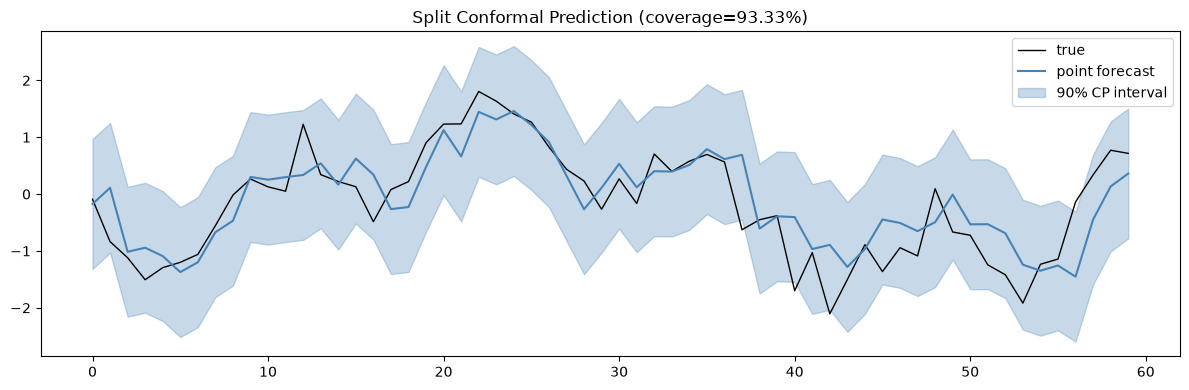

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(0)

# --- Synthetic time series ---
T = 400
t = np.arange(T)
y_ts = np.sin(2 * np.pi * t / 50) + 0.5 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 0.4, T)

# Lag features
def make_lag_features(y, lags=10):
    X, Y = [], []
    for i in range(lags, len(y)):
        X.append(y[i-lags:i])
        Y.append(y[i])
    return np.array(X), np.array(Y)

X_all, y_all = make_lag_features(y_ts, lags=10)

n_train = 250
n_cal   = 80
X_tr, y_tr = X_all[:n_train], y_all[:n_train]
X_cal, y_cal = X_all[n_train:n_train+n_cal], y_all[n_train:n_train+n_cal]
X_te, y_te = X_all[n_train+n_cal:], y_all[n_train+n_cal:]

# --- Fit point forecast model ---
model = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)
model.fit(X_tr, y_tr)

# --- Split conformal ---
scores = np.abs(y_cal - model.predict(X_cal))
alpha = 0.10  # target 90% coverage
n_cal_size = len(scores)
level = np.ceil((1 - alpha) * (1 + 1/n_cal_size)) / (1 + 1/n_cal_size)  # corrected level
q_hat = np.quantile(scores, np.ceil((1-alpha)*(1+1/n_cal_size)) / (1 + 1/n_cal_size))
# simpler: exact conformal quantile
q_hat = np.quantile(scores, min(1.0, (1-alpha)*(1 + 1/n_cal_size)))

y_pred_te = model.predict(X_te)
lower = y_pred_te - q_hat
upper = y_pred_te + q_hat

coverage = np.mean((y_te >= lower) & (y_te <= upper))
avg_width = np.mean(upper - lower)

print(f"Conformal q_hat: {q_hat:.4f}")
print(f"Test coverage:   {coverage:.3f}  (target >= {1-alpha:.2f})")
print(f"Average width:   {avg_width:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_te, label='true', color='black', lw=1)
ax.plot(y_pred_te, label='point forecast', color='steelblue', lw=1.5)
ax.fill_between(range(len(y_te)), lower, upper, alpha=0.3, color='steelblue', label=f'90% CP interval')
ax.set_title(f'Split Conformal Prediction (coverage={coverage:.2%})')
ax.legend()
plt.tight_layout()
plt.show()

### MAPIE: Production Conformal Prediction

`MAPIE` (Model Agnostic Prediction Interval Estimator) wraps any sklearn-compatible regressor and applies conformal methods including:
- `method='naive'` simple split conformal
- `method='plus'` jackknife+
- `method='minmax'` cross-conformal
- `cv='prefit'` use a pre-fitted model with separate calibration

In [3]:
# pip install mapie
try:
    from mapie.regression import MapieRegressor
    from mapie.metrics import regression_coverage_score
    MAPIE_AVAILABLE = True
except ImportError:
    MAPIE_AVAILABLE = False
    print("MAPIE not installed. Install with: pip install mapie")

if MAPIE_AVAILABLE:
    from sklearn.ensemble import GradientBoostingRegressor
    base = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)

    mapie = MapieRegressor(estimator=base, method='plus', cv=5)
    mapie.fit(X_tr, y_tr)

    y_pred_mapie, y_pis = mapie.predict(X_te, alpha=0.10)  # 90% interval
    lower_m, upper_m = y_pis[:, 0, 0], y_pis[:, 1, 0]

    cov_mapie = regression_coverage_score(y_te, lower_m, upper_m)
    print(f"MAPIE jackknife+ coverage: {cov_mapie:.3f}")
    print(f"Average width: {np.mean(upper_m - lower_m):.4f}")

MAPIE not installed. Install with: pip install mapie


## 3. DeepAR (Amazon)

**DeepAR** (Salinas et al., 2020) is an autoregressive RNN-based probabilistic forecasting model.

### Architecture

- **Encoder**: LSTM or GRU processes the conditioning window $(y_{t-L}, \ldots, y_{t-1})$ along with covariates.
- **Likelihood head**: at each future step the RNN output $h_t$ is projected to distribution parameters:
  - **Gaussian**: $\mu_t = W_\mu h_t + b_\mu$, $\sigma_t = \text{softplus}(W_\sigma h_t + b_\sigma)$
  - **Negative Binomial**: for count data (non-negative integers)
  - **Student-t**: heavier tails
- **Training**: maximize log-likelihood $\sum_t \log p(y_t | h_t)$.
- **Inference**: sample $T$ trajectories from the autoregressive decoder → empirical quantiles → prediction interval.

### Global model advantage

DeepAR trains on **all time series** simultaneously (a global model), learning cross-series patterns and enabling cold-start forecasting for new items.

In [4]:
import torch
import torch.nn as nn
import numpy as np

# Minimal DeepAR-style model (Gaussian likelihood head)
class DeepARCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.mu_head    = nn.Linear(hidden_size, 1)
        self.sigma_head = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        mu    = self.mu_head(out)                          # (B, T, 1)
        sigma = nn.functional.softplus(self.sigma_head(out)) + 1e-4  # positive
        return mu, sigma, hidden

    def gaussian_nll(self, mu, sigma, target):
        dist = torch.distributions.Normal(mu, sigma)
        return -dist.log_prob(target).mean()

    @torch.no_grad()
    def sample_forecast(self, context, n_steps, n_samples=100):
        """Autoregressive Monte Carlo sampling."""
        B = context.shape[0]
        samples = torch.zeros(B, n_samples, n_steps)
        # Encode context
        _, (h, c) = self.lstm(context)
        last_val = context[:, -1:, :]   # shape (B, 1, input_size)

        for s in range(n_samples):
            h_s, c_s = h.clone(), c.clone()
            inp = last_val.clone()
            for step in range(n_steps):
                out, (h_s, c_s) = self.lstm(inp, (h_s, c_s))
                mu_s    = self.mu_head(out)
                sigma_s = nn.functional.softplus(self.sigma_head(out)) + 1e-4
                y_s = torch.distributions.Normal(mu_s, sigma_s).sample()
                samples[:, s, step] = y_s.squeeze(-1).squeeze(-1)
                inp = y_s  # autoregressively feed back
        return samples  # (B, n_samples, n_steps)

# Quick smoke test
model_dar = DeepARCell(input_size=1, hidden_size=32, num_layers=2)
x_demo = torch.randn(4, 20, 1)  # batch=4, seq=20, features=1
mu, sigma, _ = model_dar(x_demo)
loss = model_dar.gaussian_nll(mu, sigma, x_demo)
print(f"NLL loss (demo): {loss.item():.4f}")

samples = model_dar.sample_forecast(x_demo, n_steps=10, n_samples=200)
q10 = torch.quantile(samples, 0.10, dim=1)
q90 = torch.quantile(samples, 0.90, dim=1)
print(f"Forecast samples shape: {samples.shape}")
print(f"Q10 shape: {q10.shape}, Q90 shape: {q90.shape}")

NLL loss (demo): 1.5436


Forecast samples shape: torch.Size([4, 200, 10])
Q10 shape: torch.Size([4, 10]), Q90 shape: torch.Size([4, 10])


### DeepAR with GluonTS / PyTorch-Forecasting

In production, use the official implementations:

In [5]:
# Production DeepAR with PyTorch-Forecasting
# pip install pytorch-forecasting pytorch-lightning
"""
from pytorch_forecasting import DeepAR, TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.metrics import NormalDistributionLoss

# Build dataset
dataset = TimeSeriesDataSet(
    df,
    time_idx='time_idx',
    target='value',
    group_ids=['series_id'],
    min_encoder_length=24,
    max_encoder_length=48,
    min_prediction_length=12,
    max_prediction_length=12,
    time_varying_known_reals=['time_idx'],
    time_varying_unknown_reals=['value'],
    target_normalizer=NaNLabelEncoder(),
)

# Define model
model = DeepAR.from_dataset(
    dataset,
    learning_rate=1e-3,
    hidden_size=32,
    rnn_layers=2,
    loss=NormalDistributionLoss(),
)

# Train with Lightning
trainer = pl.Trainer(max_epochs=30, gradient_clip_val=0.1)
trainer.fit(model, train_dataloader, val_dataloader)

# Predict: returns a list of sample paths
raw_predictions = model.predict(val_dataloader, mode='raw', return_x=True)
# Extract quantiles
q50 = model.predict(val_dataloader, mode='quantiles', quantiles=[0.1, 0.5, 0.9])
"""
print("DeepAR (GluonTS / PyTorch-Forecasting) API reference shown above.")
print("Key parameters:")
print("  - loss=NormalDistributionLoss() for Gaussian")
print("  - loss=NegativeBinomialDistributionLoss() for count data")
print("  - loss=MQF2DistributionLoss() for multi-quantile")

DeepAR (GluonTS / PyTorch-Forecasting) API reference shown above.
Key parameters:
  - loss=NormalDistributionLoss() for Gaussian
  - loss=NegativeBinomialDistributionLoss() for count data
  - loss=MQF2DistributionLoss() for multi-quantile


## 4. Gaussian Processes for Time Series

A **Gaussian Process** (GP) is a distribution over functions. Any finite collection of function values follows a multivariate Gaussian:

$$f(\mathbf{x}) \sim \mathcal{GP}\bigl(m(\mathbf{x}),\, k(\mathbf{x}, \mathbf{x}')\bigr)$$

where $m(\cdot)$ is the mean function and $k(\cdot, \cdot)$ is the kernel (covariance function).

### Posterior

Given observations $\mathbf{y} = f(X) + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma_n^2 I)$, the posterior at test points $X_*$ is:

$$p(f_* | X_*, X, \mathbf{y}) = \mathcal{N}(m_*, K_*)$$

$$m_* = K_{*X}(K_{XX} + \sigma_n^2 I)^{-1}\mathbf{y}$$

$$K_* = K_{**} - K_{*X}(K_{XX} + \sigma_n^2 I)^{-1}K_{X*}$$

### Kernel choices for time series

| Kernel | Formula | Use case |
|---|---|---|
| RBF (SE) | $k(r) = \sigma^2 \exp(-r^2/2l^2)$ | Smooth trends |
| Matérn 5/2 | $k(r) = \sigma^2(1+\frac{\sqrt{5}r}{l}+\frac{5r^2}{3l^2})\exp(-\frac{\sqrt{5}r}{l})$ | Rough, realistic |
| Periodic | $k(r) = \sigma^2 \exp(-2\sin^2(\pi r/p)/l^2)$ | Seasonality |
| Ornstein-Uhlenbeck | $k(r) = \sigma^2 \exp(-r/l)$ | Mean-reverting / AR(1) |

Kernels can be **combined** by addition (= independent additive components) or multiplication (= modulated structure).

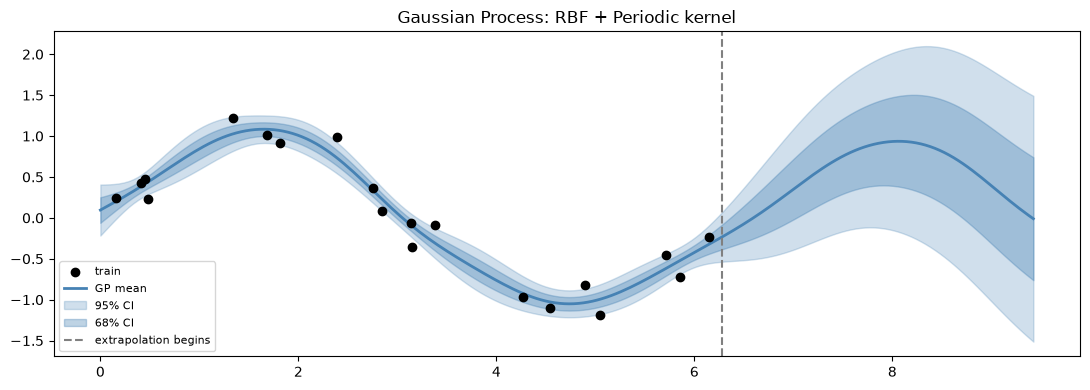

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# GP from scratch (RBF kernel, exact inference)
def rbf_kernel(X1, X2, length_scale=1.0, variance=1.0):
    diff = X1[:, None] - X2[None, :]  # (n1, n2)
    return variance * np.exp(-0.5 * (diff / length_scale)**2)

def periodic_kernel(X1, X2, period=1.0, length_scale=1.0, variance=1.0):
    diff = np.abs(X1[:, None] - X2[None, :])
    return variance * np.exp(-2 * np.sin(np.pi * diff / period)**2 / length_scale**2)

class GaussianProcess:
    def __init__(self, kernel_fn, noise=1e-2):
        self.kernel_fn = kernel_fn
        self.noise     = noise

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        K = self.kernel_fn(X_train, X_train)
        n = len(X_train)
        self.K_inv = np.linalg.inv(K + self.noise * np.eye(n))

    def predict(self, X_test):
        K_star  = self.kernel_fn(X_test, self.X_train)      # (n*, n)
        K_ss    = self.kernel_fn(X_test, X_test)            # (n*, n*)
        mu_star = K_star @ self.K_inv @ self.y_train
        cov_star = K_ss - K_star @ self.K_inv @ K_star.T
        std_star = np.sqrt(np.clip(np.diag(cov_star), 0, None))
        return mu_star, std_star

np.random.seed(7)
X_tr = np.sort(np.random.uniform(0, 2*np.pi, 20))
y_tr = np.sin(X_tr) + np.random.normal(0, 0.15, 20)
X_te = np.linspace(0, 3*np.pi, 200)

# Combine RBF (trend) + Periodic (seasonality)
def combined_kernel(X1, X2):
    return rbf_kernel(X1, X2, length_scale=3.0, variance=0.5) + \
           periodic_kernel(X1, X2, period=2*np.pi, length_scale=1.0, variance=0.5)

gp = GaussianProcess(combined_kernel, noise=0.02)
gp.fit(X_tr, y_tr)
mu, std = gp.predict(X_te)

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(X_tr, y_tr, color='black', zorder=5, label='train')
ax.plot(X_te, mu, color='steelblue', lw=2, label='GP mean')
ax.fill_between(X_te, mu - 2*std, mu + 2*std, alpha=0.25, color='steelblue', label='95% CI')
ax.fill_between(X_te, mu - std, mu + std, alpha=0.35, color='steelblue', label='68% CI')
ax.axvline(2*np.pi, ls='--', color='gray', label='extrapolation begins')
ax.set_title('Gaussian Process: RBF + Periodic kernel')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Scalable GPs with GPyTorch

Exact GP inference scales as $O(n^3)$ infeasible for large datasets. GPyTorch provides:
- **Inducing points (SVGP)**: approximate posterior using $m \ll n$ inducing inputs → $O(nm^2)$.
- **CG solver**: conjugate gradients + lazy evaluation avoids explicit matrix inversion.
- **Deep Kernel Learning**: $k(\phi(x), \phi(x'))$ where $\phi$ is a neural network.

In [7]:
# GPyTorch exact GP example
# pip install gpytorch
try:
    import torch
    import gpytorch
    GPYTORCH_AVAILABLE = True
except ImportError:
    GPYTORCH_AVAILABLE = False
    print("GPyTorch not installed. Install with: pip install gpytorch")

if GPYTORCH_AVAILABLE:
    class ExactGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            # Additive kernel: RBF trend + Periodic seasonality
            self.covar_module = (
                gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel()) +
                gpytorch.kernels.ScaleKernel(gpytorch.kernels.PeriodicKernel())
            )

        def forward(self, x):
            mean_x  = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    train_x = torch.FloatTensor(X_tr)
    train_y = torch.FloatTensor(y_tr)
    test_x  = torch.FloatTensor(X_te)

    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    gp_model   = ExactGPModel(train_x, train_y, likelihood)

    # Train
    gp_model.train(); likelihood.train()
    optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)

    for i in range(100):
        optimizer.zero_grad()
        output = gp_model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()

    # Predict
    gp_model.eval(); likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(gp_model(test_x))
        lower_gp, upper_gp = pred.confidence_region()  # 2-sigma

    print(f"GPyTorch training complete. Final NLL: {loss.item():.4f}")
    print(f"Learned RBF lengthscale: {gp_model.covar_module.kernels[0].base_kernel.lengthscale.item():.3f}")

GPyTorch not installed. Install with: pip install gpytorch


## 5. NGBoost Natural Gradient Boosting

**NGBoost** (Duan et al., 2020) is a boosting algorithm that fits a **probability distribution** rather than a point estimate.

### Key idea

Standard gradient boosting computes the Euclidean gradient $\nabla_{\theta} \ell(\theta)$ in parameter space. NGBoost uses the **natural gradient**:

$$\tilde{\nabla}_{\theta} \ell = F^{-1}(\theta) \nabla_{\theta} \ell$$

where $F(\theta) = \mathbb{E}[\nabla \log p \, (\nabla \log p)^\top]$ is the **Fisher information matrix**. This gradient is invariant to reparameterisation and moves in the direction of steepest descent in *distribution space*.

The result: at each step, NGBoost fits a base learner to the natural gradient residuals, producing distribution forecasts (e.g. Normal, LogNormal) with well-calibrated uncertainty.

In [8]:
# pip install ngboost
try:
    from ngboost import NGBRegressor
    from ngboost.distns import Normal, LogNormal
    NGBOOST_AVAILABLE = True
except ImportError:
    NGBOOST_AVAILABLE = False
    print("NGBoost not installed. Install with: pip install ngboost")

import numpy as np
np.random.seed(42)

# Synthetic regression dataset
X_ngb = np.random.uniform(0, 10, (600, 3))
y_ngb = X_ngb[:, 0] * np.sin(X_ngb[:, 1]) + np.random.normal(0, 0.5 + 0.1*X_ngb[:, 0], 600)

split = 480
X_tr_n, X_te_n = X_ngb[:split], X_ngb[split:]
y_tr_n, y_te_n = y_ngb[:split], y_ngb[split:]

if NGBOOST_AVAILABLE:
    ngb = NGBRegressor(Dist=Normal, n_estimators=300, verbose=False)
    ngb.fit(X_tr_n, y_tr_n)

    # Predict returns a distribution object
    y_dists = ngb.pred_dist(X_te_n)
    mu_ngb  = y_dists.mean()
    std_ngb = y_dists.std()

    lower_ngb = mu_ngb - 1.645 * std_ngb  # 90% interval
    upper_ngb = mu_ngb + 1.645 * std_ngb

    coverage_ngb = np.mean((y_te_n >= lower_ngb) & (y_te_n <= upper_ngb))
    print(f"NGBoost 90% coverage: {coverage_ngb:.3f}  (target 0.900)")
    print(f"Mean predicted std:   {std_ngb.mean():.4f}")
else:
    # Show what NGBoost API looks like
    print("""NGBoost API:
  ngb = NGBRegressor(Dist=Normal, n_estimators=500)
  ngb.fit(X_train, y_train)
  dist = ngb.pred_dist(X_test)
  mu, sigma = dist.mean(), dist.std()
  # Interval
  lower = dist.ppf(0.05)   # 5th percentile
  upper = dist.ppf(0.95)   # 95th percentile
""")

/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/tree/_classes.py:1351: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warnings.warn(


NGBoost 90% coverage: 0.892  (target 0.900)
Mean predicted std:   1.5915


## 6. MC Dropout Bayesian Approximation

**MC Dropout** (Gal & Ghahramani, 2016) shows that a neural network trained with dropout is equivalent to approximate Bayesian inference in a deep GP.

### Recipe

1. Train a neural network with dropout (standard).
2. At **test time**, **keep dropout active** (do not switch to `model.eval()`).
3. Run $T$ forward passes with the same input $x^*$; each pass samples a different dropout mask, giving predictions $\hat{y}_1, \ldots, \hat{y}_T$.
4. Estimate uncertainty:
   - Predictive mean: $\bar{y} = \frac{1}{T}\sum_{t=1}^T \hat{y}_t$
   - Predictive variance: $\hat{\sigma}^2 = \frac{1}{T}\sum_{t=1}^T \hat{y}_t^2 - \bar{y}^2 + \tau^{-1}$

where $\tau^{-1}$ is the model precision (regularisation-dependent).

**Cost**: inference is $T \times$ more expensive than a standard forward pass typically $T=50$-$200$.

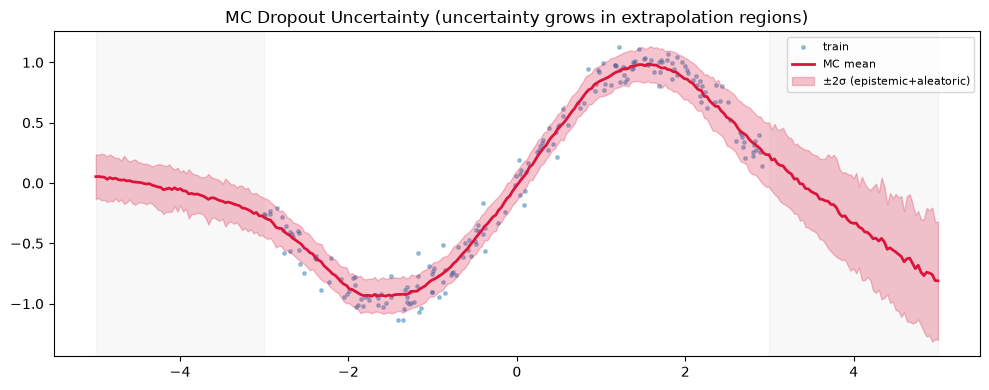

Uncertainty in-distribution (|x|<2): 0.0696
Uncertainty out-of-distribution: 0.0868


In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class MCDropoutNet(nn.Module):
    def __init__(self, input_dim=1, hidden=64, dropout_p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x)

    def mc_predict(self, x, T=100):
        """Keep dropout ON during inference for T forward passes."""
        self.train()  # IMPORTANT: keeps dropout active
        preds = torch.stack([self(x) for _ in range(T)], dim=0)  # (T, B, 1)
        mean = preds.mean(0)
        std  = preds.std(0)
        return mean, std

# Generate toy data
torch.manual_seed(0)
X_mc = torch.FloatTensor(np.sort(np.random.uniform(-3, 3, 200)).reshape(-1, 1))
y_mc = torch.sin(X_mc) + 0.1 * torch.randn_like(X_mc)

# Train
mc_model = MCDropoutNet(dropout_p=0.05)
opt = torch.optim.Adam(mc_model.parameters(), lr=1e-3, weight_decay=1e-4)
mc_model.train()
for epoch in range(500):
    opt.zero_grad()
    loss = nn.MSELoss()(mc_model(X_mc), y_mc)
    loss.backward()
    opt.step()

# Predict with uncertainty on wider range (includes extrapolation)
X_eval = torch.FloatTensor(np.linspace(-5, 5, 300).reshape(-1, 1))
with torch.no_grad():
    mean_mc, std_mc = mc_model.mc_predict(X_eval, T=200)

mean_mc = mean_mc.numpy().ravel()
std_mc  = std_mc.numpy().ravel()
X_eval_np = X_eval.numpy().ravel()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(X_mc.numpy(), y_mc.numpy(), s=6, alpha=0.4, label='train')
ax.plot(X_eval_np, mean_mc, color='crimson', lw=2, label='MC mean')
ax.fill_between(X_eval_np, mean_mc - 2*std_mc, mean_mc + 2*std_mc,
                alpha=0.25, color='crimson', label='±2σ (epistemic+aleatoric)')
ax.axvspan(-5, -3, alpha=0.05, color='gray'); ax.axvspan(3, 5, alpha=0.05, color='gray')
ax.set_title('MC Dropout Uncertainty (uncertainty grows in extrapolation regions)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Uncertainty in-distribution (|x|<2): {std_mc[75:225].mean():.4f}")
print(f"Uncertainty out-of-distribution: {std_mc[:50].mean():.4f}")

## 7. Deep Ensembles

**Deep Ensembles** (Lakshminarayanan et al., 2017) are one of the most practical and well-calibrated uncertainty methods.

### Algorithm

1. Train $N$ independent neural networks $\{\hat{\mu}_i(x), \hat{\sigma}_i(x)\}_{i=1}^N$ with different random initialisations, each with a **Gaussian likelihood head**.
2. Aggregate predictions as a **mixture of Gaussians**:

$$\mu^*(x) = \frac{1}{N}\sum_{i=1}^N \hat{\mu}_i(x)$$

$$\sigma^{*2}(x) = \frac{1}{N}\sum_{i=1}^N \bigl(\hat{\sigma}_i^2(x) + \hat{\mu}_i^2(x)\bigr) - \mu^{*2}(x)$$

The variance decomposes into:
- $\frac{1}{N}\sum \hat{\sigma}_i^2$ **aleatoric** (irreducible noise)
- $\frac{1}{N}\sum(\hat{\mu}_i - \mu^*)^2$ **epistemic** (model uncertainty)

### Why it works

Different initialisations explore different loss basins, providing diverse predictions. In OOD regions the models disagree more → larger epistemic uncertainty.

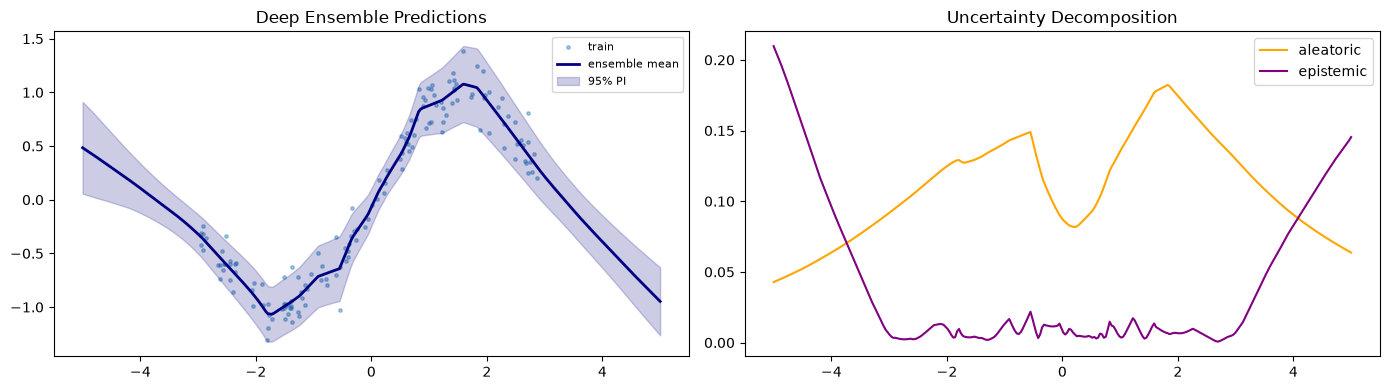

Ensemble trained with 5 members.


In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class GaussianHeadNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.mu_head    = nn.Linear(hidden, 1)
        self.sigma_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.backbone(x)
        mu    = self.mu_head(h)
        sigma = nn.functional.softplus(self.sigma_head(h)) + 1e-4
        return mu, sigma

    def nll_loss(self, x, y):
        mu, sigma = self(x)
        return -torch.distributions.Normal(mu, sigma).log_prob(y).mean()

def train_member(X, y, epochs=600, lr=1e-3):
    m = GaussianHeadNet()
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        m.nll_loss(X, y).backward()
        opt.step()
    return m

torch.manual_seed(1)
X_ens = torch.FloatTensor(np.sort(np.random.uniform(-3, 3, 150)).reshape(-1, 1))
y_ens = torch.sin(X_ens) + 0.15 * torch.randn_like(X_ens)

N_ENSEMBLE = 5
members = [train_member(X_ens, y_ens) for _ in range(N_ENSEMBLE)]

X_eval = torch.FloatTensor(np.linspace(-5, 5, 300).reshape(-1, 1))
all_mu, all_sigma2 = [], []
for m in members:
    m.eval()
    with torch.no_grad():
        mu_i, sigma_i = m(X_eval)
    all_mu.append(mu_i.numpy().ravel())
    all_sigma2.append(sigma_i.numpy().ravel()**2)

mu_stack    = np.stack(all_mu)     # (N, T)
sigma2_stack = np.stack(all_sigma2)

mu_star    = mu_stack.mean(0)
sigma2_star = (sigma2_stack + mu_stack**2).mean(0) - mu_star**2
std_star   = np.sqrt(sigma2_star)

aleatoric  = np.sqrt(sigma2_stack.mean(0))
epistemic  = np.sqrt(np.mean((mu_stack - mu_star)**2, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.scatter(X_ens.numpy(), y_ens.numpy(), s=6, alpha=0.4, label='train')
ax.plot(X_eval.numpy(), mu_star, color='navy', lw=2, label='ensemble mean')
ax.fill_between(X_eval.numpy().ravel(), mu_star - 2*std_star, mu_star + 2*std_star,
                alpha=0.2, color='navy', label='95% PI')
ax.set_title('Deep Ensemble Predictions'); ax.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(X_eval.numpy(), aleatoric, label='aleatoric', color='orange')
ax2.plot(X_eval.numpy(), epistemic, label='epistemic', color='purple')
ax2.set_title('Uncertainty Decomposition'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"Ensemble trained with {N_ENSEMBLE} members.")

## 8. BSTS Bayesian Structural Time Series

**BSTS** decomposes a time series into interpretable components using a **state-space model**:

$$y_t = Z_t^\top \alpha_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_{\varepsilon}^2)$$

$$\alpha_{t+1} = T_t \alpha_t + R_t \eta_t, \quad \eta_t \sim \mathcal{N}(0, Q_t)$$

where $\alpha_t$ is the latent state vector. Components can include:

| Component | State dimension | Description |
|---|---|---|
| Local level | 1 | Random-walk trend |
| Local linear trend | 2 | Slope + level |
| Seasonal (period $S$) | $S-1$ | Dummy-variable seasonality |
| Regression | $p$ | Spike-and-slab variable selection |

### Inference

The posterior $p(\alpha_{1:T}, \theta | y_{1:T})$ is sampled via:
1. **Kalman filter** (forward pass): computes $p(\alpha_t | y_{1:t})$.
2. **FFBS** (Forward-Filter Backward-Smoother / disturbance smoother): samples the state trajectory.
3. **MCMC** for hyperparameters $\theta$.

### CausalImpact

Google's `CausalImpact` uses BSTS to estimate causal effects of interventions by forecasting the **counterfactual** (what would have happened without the intervention) using a control time series as regressor.

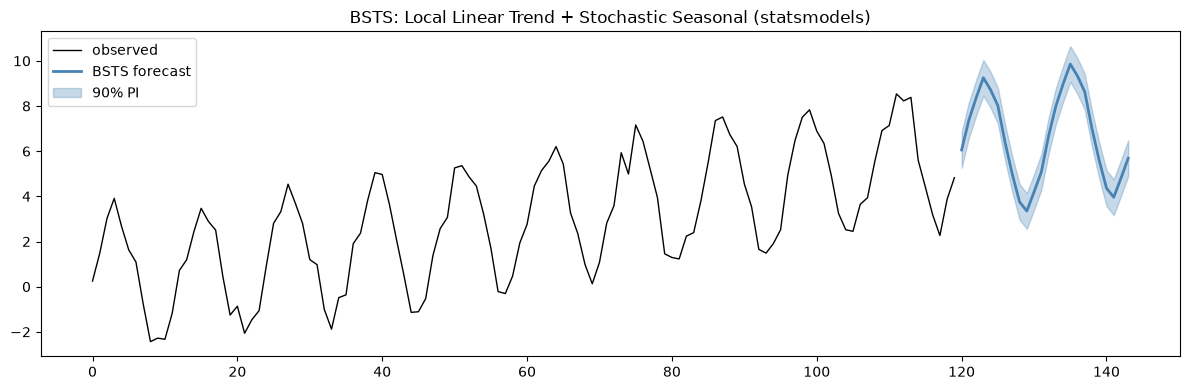

                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                  120
Model:                    local linear trend   Log Likelihood                 -83.999
                   + stochastic seasonal(12)   AIC                            175.997
Date:                       Fri, 19 Jun 2026   BIC                            186.689
Time:                               14:40:22   HQIC                           180.331
Sample:                                    0                                         
                                       - 120                                         
Covariance Type:                         opg                                         


In [11]:
# BSTS with statsmodels UnobservedComponents
import numpy as np
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
    SM_AVAILABLE = True
except ImportError:
    SM_AVAILABLE = False

np.random.seed(42)
T = 120
t = np.arange(T)
trend = 0.05 * t
seasonal = 3.0 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(0, 0.5, T)
y_bsts = trend + seasonal + noise

if SM_AVAILABLE:
    # Local linear trend + seasonal 12-period
    model_uc = sm.tsa.UnobservedComponents(
        y_bsts,
        level='local linear trend',
        seasonal=12,
        stochastic_seasonal=True
    )
    result = model_uc.fit(disp=False)

    # Forecast 24 steps ahead with prediction intervals
    forecast = result.get_forecast(24)
    forecast_mean = forecast.predicted_mean
    ci = forecast.conf_int(alpha=0.10)  # 90% interval

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, y_bsts, label='observed', color='black', lw=1)
    fcast_t = np.arange(T, T+24)
    ax.plot(fcast_t, forecast_mean, color='steelblue', lw=2, label='BSTS forecast')
    ci = np.asarray(ci)
    ax.fill_between(fcast_t, ci[:, 0], ci[:, 1],
                    alpha=0.3, color='steelblue', label='90% PI')
    ax.set_title('BSTS: Local Linear Trend + Stochastic Seasonal (statsmodels)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(result.summary().tables[0])
else:
    print("statsmodels not available. Install with: pip install statsmodels")
    print("BSTS alternatives: tfp.sts (TensorFlow Probability), R bsts package")

## 9. Modern Neural Forecasters Architecture Survey

The past three years saw an explosion of transformer-based and MLP-based architectures for long-range forecasting. Here is a concise reference.

### TFT Temporal Fusion Transformer

- Multi-horizon; uses static covariates, time-varying known/unknown inputs.
- **Variable Selection Networks (VSN)** prune irrelevant features.
- Outputs **quantile forecasts** directly via multi-head quantile loss.
- Attention over time → interpretable importance weights.

### NeuralProphet

- Extends Prophet with neural components (AR-Net, covariates via FFNNs).
- **Probabilistic mode**: adds a Laplace distribution head for uncertainty.
- API mirrors Prophet for easy adoption.

### N-BEATS Neural Basis Expansion

Pure MLP architecture. Each block learns **basis expansion**:
$$\hat{y}_t = \sum_k \theta_k^b \, v_k^{\text{backcast}} + \sum_k \theta_k^f \, v_k^{\text{forecast}}$$

In the **interpretable** version, basis vectors are fixed: polynomial ($V^{\text{trend}}$) and Fourier ($V^{\text{seasonality}}$) giving decomposition for free.

### PatchTST (2023)

- **Patches**: divide the sequence into non-overlapping windows of length $P$, treat each as a token (analogous to image patches in ViT).
- **Channel independence**: each variate is encoded independently → avoids spurious cross-variate attention.
- Attention is over $\lceil L/P \rceil$ patch tokens instead of $L$ time steps → much cheaper.

### TiDE Time-series Dense Encoder

MLP-Mixer alternative to transformers:
1. **Encode**: dense encoder maps covariates + past $y$ → latent representation.
2. **Project**: temporal projection layer.
3. **Decode**: dense decoder maps latent → future $\hat{y}$.

FLOP-efficient, often matches or beats transformer baselines.

### TimesNet (2023)

Key insight: temporal variations often have **multi-periodicity**. TimesNet:
1. Find top-$k$ periods $\{p_1, \ldots, p_k\}$ via FFT of the input.
2. **Reshape** 1D signal of length $T$ into 2D matrix of shape $\lceil T/p \rceil \times p$.
3. Apply **2D convolution** (TimesBlock) to capture intra-period and inter-period variation simultaneously.

### DLinear Decomposition + Linear

Surprisingly strong baseline (Wu et al., 2023):
1. Decompose: moving-average filter → **trend** component; residual → **seasonality** component.
2. Apply a **separate linear layer** to each component.
3. Sum the forecasts.

Demonstrates that simple linear models on decomposed series beat many transformers.

### iTransformer (2024)

- **Inverts** the attention axis: instead of treating time steps as tokens, treat **each variable (channel) as a token**.
- Attention captures cross-variable dependencies; FFN models per-variable temporal patterns.
- State-of-the-art on multivariate long-range benchmarks (ETTh, Weather, Traffic).

In [12]:
import torch
import torch.nn as nn
import numpy as np

# --- DLinear: Decomposition + Linear (reference implementation) ---
class MovingAvg(nn.Module):
    """Moving average to extract trend."""
    def __init__(self, kernel_size=25, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # x: (B, T, C)
        front = x[:, 0:1, :].repeat(1, self.kernel_size // 2, 1)
        end   = x[:, -1:, :].repeat(1, self.kernel_size // 2, 1)
        x_pad = torch.cat([front, x, end], dim=1)
        x_pad = x_pad.permute(0, 2, 1)  # (B, C, T+pad)
        trend = self.avg(x_pad).permute(0, 2, 1)
        return trend

class DLinear(nn.Module):
    def __init__(self, seq_len=96, pred_len=24, enc_in=7, individual=True):
        super().__init__()
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.decomp   = MovingAvg(kernel_size=25)
        self.individual = individual

        if individual:
            # One linear layer per channel
            self.linear_trend    = nn.ModuleList([nn.Linear(seq_len, pred_len) for _ in range(enc_in)])
            self.linear_seasonal = nn.ModuleList([nn.Linear(seq_len, pred_len) for _ in range(enc_in)])
        else:
            self.linear_trend    = nn.Linear(seq_len, pred_len)
            self.linear_seasonal = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        # x: (B, T, C)
        trend    = self.decomp(x)
        seasonal = x - trend

        if self.individual:
            out_t = torch.stack([self.linear_trend[i](trend[:, :, i])    for i in range(x.shape[-1])], dim=-1)
            out_s = torch.stack([self.linear_seasonal[i](seasonal[:, :, i]) for i in range(x.shape[-1])], dim=-1)
        else:
            out_t = self.linear_trend(trend.permute(0,2,1)).permute(0,2,1)
            out_s = self.linear_seasonal(seasonal.permute(0,2,1)).permute(0,2,1)

        return out_t + out_s  # (B, pred_len, C)

# Quick smoke test
model_dlin = DLinear(seq_len=96, pred_len=24, enc_in=7)
x_demo = torch.randn(8, 96, 7)  # batch=8, seq=96, channels=7
out = model_dlin(x_demo)
print(f"DLinear input:  {x_demo.shape}")
print(f"DLinear output: {out.shape}  (expected [8, 24, 7])")
print(f"Parameters: {sum(p.numel() for p in model_dlin.parameters()):,}")

DLinear input:  torch.Size([8, 96, 7])
DLinear output: torch.Size([8, 24, 7])  (expected [8, 24, 7])
Parameters: 32,592


In [13]:
import torch
import torch.nn as nn

# --- PatchTST: Patching + Channel Independence ---
class PatchTST(nn.Module):
    """
    Simplified PatchTST (Nie et al., 2023).
    Channel-independent: each variate processed independently.
    """
    def __init__(self, seq_len=96, pred_len=24, patch_len=16, stride=8,
                 d_model=128, n_heads=8, n_layers=3, dropout=0.1):
        super().__init__()
        self.patch_len = patch_len
        self.stride    = stride
        n_patches = (seq_len - patch_len) // stride + 1

        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed   = nn.Parameter(torch.zeros(1, n_patches, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True
        )
        self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head      = nn.Linear(n_patches * d_model, pred_len)
        self.n_patches = n_patches
        self.d_model   = d_model

    def forward(self, x):
        # x: (B, T, C)  → process each channel independently
        B, T, C = x.shape
        x = x.permute(0, 2, 1)          # (B, C, T)
        x = x.reshape(B * C, T)          # (B*C, T)

        # Patchify
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)  # (B*C, n_patches, patch_len)
        patches = self.patch_embed(patches) + self.pos_embed  # (B*C, n_patches, d_model)

        # Transformer encoder
        enc_out = self.encoder(patches)   # (B*C, n_patches, d_model)
        enc_flat = enc_out.reshape(B * C, self.n_patches * self.d_model)

        # Projection head
        out = self.head(enc_flat)         # (B*C, pred_len)
        out = out.reshape(B, C, -1).permute(0, 2, 1)  # (B, pred_len, C)
        return out

patch_tst = PatchTST(seq_len=96, pred_len=24, patch_len=16, stride=8)
x_in = torch.randn(4, 96, 7)
y_out = patch_tst(x_in)
print(f"PatchTST  input:  {x_in.shape}")
print(f"PatchTST  output: {y_out.shape}  (expected [4, 24, 7])")
print(f"Num patches: {patch_tst.n_patches}")
print(f"Parameters: {sum(p.numel() for p in patch_tst.parameters()):,}")

PatchTST  input:  torch.Size([4, 96, 7])
PatchTST  output: torch.Size([4, 24, 7])  (expected [4, 24, 7])
Num patches: 11
Parameters: 632,216


In [14]:
import torch
import torch.nn as nn

# --- iTransformer: Inverted Attention (Liu et al., 2024) ---
class iTransformerBlock(nn.Module):
    """
    Inverted Transformer block:
    - Each variate is a token of dimension T (sequence length)
    - Attention captures cross-variate dependencies
    - FFN captures per-variate temporal patterns
    """
    def __init__(self, n_vars, seq_len, d_model=64, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        # x: (B, C, d_model) each variate already embedded as a token
        x_emb = x
        # Self-attention over variates
        attn_out, _ = self.attn(x_emb, x_emb, x_emb)
        x_emb = self.norm1(x_emb + attn_out)
        x_emb = self.norm2(x_emb + self.ffn(x_emb))
        return x_emb  # (B, C, d_model)

class iTransformer(nn.Module):
    def __init__(self, seq_len=96, pred_len=24, n_vars=7, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.enc_embedding = nn.Linear(seq_len, d_model)  # embed each variate token once
        self.layers = nn.ModuleList([
            iTransformerBlock(n_vars, seq_len, d_model, n_heads) for _ in range(n_layers)
        ])
        self.proj = nn.Linear(d_model, pred_len)

    def forward(self, x):
        # x: (B, T, C)
        x = x.permute(0, 2, 1)   # (B, C, T) invert!
        x = self.enc_embedding(x)  # (B, C, d_model)
        for layer in self.layers:
            x = layer(x)
        out = self.proj(x)        # (B, C, pred_len)
        return out.permute(0, 2, 1)  # (B, pred_len, C)

itrans = iTransformer(seq_len=96, pred_len=24, n_vars=7)
x_in = torch.randn(4, 96, 7)
out  = itrans(x_in)
print(f"iTransformer input:  {x_in.shape}")
print(f"iTransformer output: {out.shape}  (expected [4, 24, 7])")
print(f"Parameters: {sum(p.numel() for p in itrans.parameters()):,}")

iTransformer input:  torch.Size([4, 96, 7])
iTransformer output: torch.Size([4, 24, 7])  (expected [4, 24, 7])
Parameters: 107,736


## 10. Calibration Metrics

A probabilistic forecast is **calibrated** if predicted probabilities match empirical frequencies. Beyond coverage, we need metrics that reward **sharpness** (narrow intervals) while penalising over-confidence.

### Reliability Diagram (Calibration Plot)

For each predicted quantile $\tau$, plot the empirical coverage $\hat{P}(y \leq \hat{Q}_\tau)$. A perfectly calibrated model lies on the diagonal $y = x$.

### Coverage Rate

$$\text{CR}_{1-\alpha} = \frac{1}{n}\sum_{i=1}^n \mathbf{1}[y_i \in [l_i, u_i]]$$

### Interval Score (Winkler Score)

$$\text{IS}_\alpha(l, u, y) = (u - l) + \frac{2}{\alpha}(l - y)\mathbf{1}[y < l] + \frac{2}{\alpha}(y - u)\mathbf{1}[y > u]$$

Lower is better. Rewards narrow intervals and penalises miscoverage by $2/\alpha$.

### Continuous Ranked Probability Score (CRPS)

$$\text{CRPS}(F, y) = \int_{-\infty}^{\infty} \bigl[F(z) - \mathbf{1}[z \geq y]\bigr]^2 dz$$

Generalises MAE to distributional forecasts. CRPS = MAE when $F$ is a Dirac delta.

### Energy Score

Multivariate generalisation of CRPS:
$$\text{ES}(F, y) = \mathbb{E}\|X - y\| - \frac{1}{2}\mathbb{E}\|X - X'\|$$

where $X, X' \sim F$ are independent samples from the forecast distribution.

Calibrated      | Coverage: 0.898 | IS: 4.1054 | CRPS: 0.5574
Overconfident   | Coverage: 0.492 | IS: 7.3102 | CRPS: 0.6234


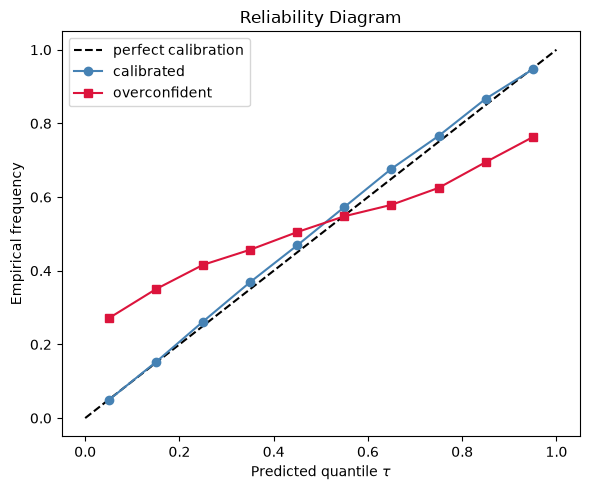

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)

# Simulate two forecasters: calibrated vs overconfident
n = 1000
y_true = np.random.normal(0, 1, n)

# Calibrated: predicted std ≈ true std
mu_cal    = np.zeros(n)
sigma_cal = np.ones(n)

# Overconfident: predicted std too small
mu_oc    = np.zeros(n)
sigma_oc = 0.4 * np.ones(n)

# --- Reliability diagram ---
def reliability_diagram(y_true, mu, sigma, n_bins=10):
    taus = np.linspace(0.05, 0.95, n_bins)
    empirical = []
    for tau in taus:
        q = stats.norm.ppf(tau, loc=mu, scale=sigma)
        empirical.append(np.mean(y_true <= q))
    return taus, np.array(empirical)

taus, emp_cal = reliability_diagram(y_true, mu_cal, sigma_cal)
taus, emp_oc  = reliability_diagram(y_true, mu_oc,  sigma_oc)

# --- Interval Score ---
def interval_score(y, lower, upper, alpha):
    width = upper - lower
    penalty_l = (2 / alpha) * np.maximum(lower - y, 0)
    penalty_u = (2 / alpha) * np.maximum(y - upper, 0)
    return np.mean(width + penalty_l + penalty_u)

# --- CRPS (Gaussian closed form) ---
def crps_gaussian(y, mu, sigma):
    z = (y - mu) / sigma
    return np.mean(sigma * (z * (2*stats.norm.cdf(z) - 1) +
                            2*stats.norm.pdf(z) - 1/np.sqrt(np.pi)))

alpha = 0.10
for name, mu, sigma in [('Calibrated', mu_cal, sigma_cal), ('Overconfident', mu_oc, sigma_oc)]:
    l = stats.norm.ppf(alpha/2, mu, sigma)
    u = stats.norm.ppf(1-alpha/2, mu, sigma)
    cr  = np.mean((y_true >= l) & (y_true <= u))
    IS  = interval_score(y_true, l, u, alpha)
    crps = crps_gaussian(y_true, mu, sigma)
    print(f"{name:15s} | Coverage: {cr:.3f} | IS: {IS:.4f} | CRPS: {crps:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
ax.plot(taus, emp_cal, 'o-', color='steelblue', label='calibrated')
ax.plot(taus, emp_oc,  's-', color='crimson',   label='overconfident')
ax.set_xlabel('Predicted quantile $\\tau$')
ax.set_ylabel('Empirical frequency')
ax.set_title('Reliability Diagram')
ax.legend()
plt.tight_layout(); plt.show()

## 11. End-to-End: Conformal + MAPIE on Real-Style Data

90% coverage on test: 0.938  (target >= 0.90)
Average interval width: 3.305
Interval Score (IS_0.1): 3.7348


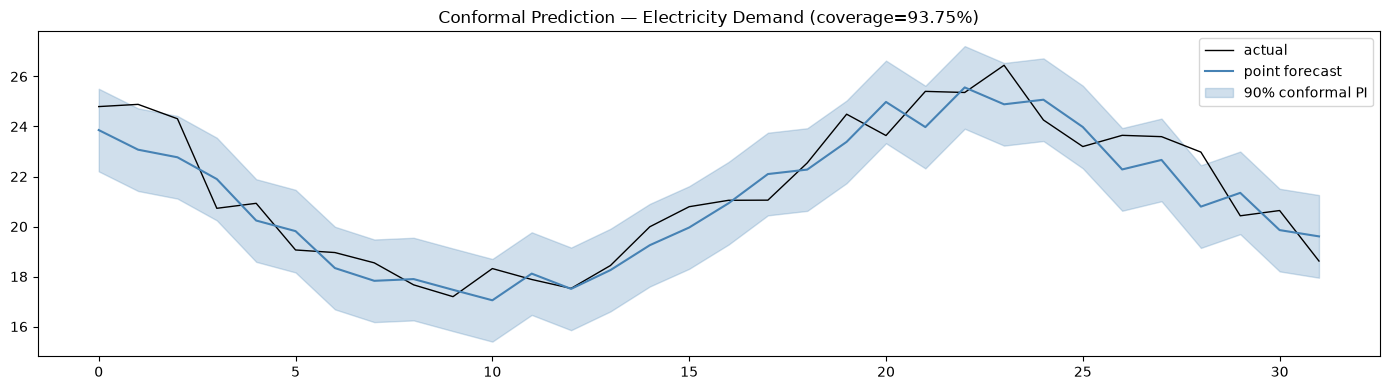

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(123)

# Simulate electricity demand-like time series
T_total = 1000
t = np.arange(T_total)
trend     = 0.003 * t
daily     = 4.0  * np.sin(2 * np.pi * t / 24)
weekly    = 2.0  * np.sin(2 * np.pi * t / (24 * 7))
noise     = np.random.normal(0, 0.8, T_total)
y_demand  = trend + daily + weekly + noise + 20

# Feature engineering
def build_features(y, lags=[1, 2, 3, 24, 48, 168], rolling=[6, 24]):
    max_lag = max(lags + rolling)
    rows = []
    for i in range(max_lag, len(y)):
        feats = [y[i - lag] for lag in lags]
        feats += [y[i-w:i].mean() for w in rolling]
        feats += [i % 24, (i // 24) % 7]  # hour_of_day, day_of_week
        rows.append(feats)
    return np.array(rows), y[max_lag:]

X_feat, y_feat = build_features(y_demand)

split_tr  = 600
split_cal = 800
X_tr_d,  y_tr_d  = X_feat[:split_tr],             y_feat[:split_tr]
X_cal_d, y_cal_d = X_feat[split_tr:split_cal],   y_feat[split_tr:split_cal]
X_te_d,  y_te_d  = X_feat[split_cal:],            y_feat[split_cal:]

scaler = StandardScaler()
X_tr_d_s  = scaler.fit_transform(X_tr_d)
X_cal_d_s = scaler.transform(X_cal_d)
X_te_d_s  = scaler.transform(X_te_d)

# Train GBM
gbm = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05)
gbm.fit(X_tr_d_s, y_tr_d)

# Conformal calibration (split conformal)
residuals = np.abs(y_cal_d - gbm.predict(X_cal_d_s))
q90 = np.quantile(residuals, 0.90 * (1 + 1/len(residuals)))

y_pred_te_d = gbm.predict(X_te_d_s)
lo90 = y_pred_te_d - q90
hi90 = y_pred_te_d + q90
cov90 = np.mean((y_te_d >= lo90) & (y_te_d <= hi90))

alpha_IS = 0.10
IS = np.mean(
    (hi90 - lo90) +
    (2/alpha_IS) * np.maximum(lo90 - y_te_d, 0) +
    (2/alpha_IS) * np.maximum(y_te_d - hi90, 0)
)

print(f"90% coverage on test: {cov90:.3f}  (target >= 0.90)")
print(f"Average interval width: {(hi90 - lo90).mean():.3f}")
print(f"Interval Score (IS_0.1): {IS:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
idx_plot = np.arange(min(200, len(y_te_d)))
ax.plot(idx_plot, y_te_d[:200], color='black', lw=1, label='actual')
ax.plot(idx_plot, y_pred_te_d[:200], color='steelblue', lw=1.5, label='point forecast')
ax.fill_between(idx_plot, lo90[:200], hi90[:200],
                alpha=0.25, color='steelblue', label='90% conformal PI')
ax.set_title(f'Conformal Prediction Electricity Demand (coverage={cov90:.2%})')
ax.legend(); plt.tight_layout(); plt.show()

## 12. Choosing the Right Method

| Method | Coverage guarantee | Distributional assumption | Scale | Best for |
|---|---|---|---|---|
| Quantile Regression | No (relies on model) | None | Medium | Tabular, tree-based |
| Conformal Prediction | Yes (finite-sample) | None | Any | Any black-box model |
| DeepAR | No (parametric) | Gaussian / NegBin / Student-t | Large | Multiple series, global model |
| GP | Yes (Bayesian posterior) | GP prior | Small-Medium | Small data, smooth functions |
| NGBoost | No (parametric) | Chosen distribution | Medium | Tabular, interpretable |
| MC Dropout | Approximate | Implicit | Medium | Existing NN, cheap retrofit |
| Deep Ensembles | Approximate | Implicit | Large | Best practical uncertainty |
| BSTS | Yes (Bayesian posterior) | State space Gaussian | Medium | Interpretable decomposition, causality |

### Decision flowchart

```
Need finite-sample guarantee? ──Yes──▶ Conformal Prediction
        │
        No
        │
        ▼
Tabular / tree-based?  ──Yes──▶ NGBoost or QRF
        │
        No
        │
        ▼
Many short series?  ──Yes──▶ DeepAR (global model)
        │
        No
        │
        ▼
Small dataset? ──Yes──▶ Gaussian Process
        │
        No
        │
        ▼
Existing NN?  ──Yes──▶ MC Dropout or Deep Ensembles
```

## 13. Quick-Reference: Uncertainty Decomposition

Total predictive uncertainty = **aleatoric** + **epistemic**:

$$\underbrace{\text{Var}[y|x]}_{\text{total}} = \underbrace{\mathbb{E}_{\theta}[\text{Var}[y|x,\theta]]}_{\text{aleatoric}} + \underbrace{\text{Var}_{\theta}[\mathbb{E}[y|x,\theta]]}_{\text{epistemic}}$$

| Type | Source | Reducible? | Captured by |
|---|---|---|---|
| **Aleatoric** | Inherent noise in data | No | Likelihood head variance |
| **Epistemic** | Limited / OOD data | Yes (more data) | Model disagreement (ensembles, MC dropout) |

In [17]:
# Summary: key formula implementations in one place
import numpy as np

# 1. Pinball loss
pinball = lambda y, yhat, tau: np.mean((y - yhat) * (tau - (y < yhat).astype(float)))

# 2. Coverage rate
coverage_rate = lambda y, lo, hi: np.mean((y >= lo) & (y <= hi))

# 3. Interval Score (Winkler)
interval_score = lambda y, lo, hi, a: np.mean(
    (hi - lo) + (2/a)*np.maximum(lo-y, 0) + (2/a)*np.maximum(y-hi, 0)
)

# 4. CRPS (Gaussian closed form)
from scipy.stats import norm as _norm
def crps_gaussian(y, mu, sigma):
    z = (y - mu) / sigma
    return np.mean(sigma * (z*(2*_norm.cdf(z)-1) + 2*_norm.pdf(z) - 1/np.sqrt(np.pi)))

# 5. Deep Ensemble aggregation
def ensemble_aggregate(mus, sigmas):
    """mus, sigmas: arrays of shape (N_members, n_points)"""
    mu_star    = mus.mean(axis=0)
    var_star   = (sigmas**2 + mus**2).mean(axis=0) - mu_star**2
    return mu_star, np.sqrt(var_star)

# Demo
np.random.seed(0)
y_demo  = np.random.normal(5, 1, 500)
mu_demo = np.full(500, 5.0)
sg_demo = np.full(500, 1.0)
lo_demo = _norm.ppf(0.05, mu_demo, sg_demo)
hi_demo = _norm.ppf(0.95, mu_demo, sg_demo)

print("=== Calibration Metrics Demo ===")
print(f"Coverage 90%:    {coverage_rate(y_demo, lo_demo, hi_demo):.3f}")
print(f"Interval Score:  {interval_score(y_demo, lo_demo, hi_demo, 0.10):.4f}")
print(f"CRPS (Gaussian): {crps_gaussian(y_demo, mu_demo, sg_demo):.4f}")
print(f"Pinball Q90:     {pinball(y_demo, hi_demo, 0.90):.4f}")

=== Calibration Metrics Demo ===
Coverage 90%:    0.892
Interval Score:  4.1279
CRPS (Gaussian): 0.5645
Pinball Q90:     0.1880


## Additional Learning Resources

### Foundational Papers

| Paper | Key contribution |
|---|---|
| Koenker & Bassett (1978) *Regression Quantiles* | Pinball loss, quantile regression foundations |
| Vovk et al. (2005) *Algorithmic Learning in a Random World* | Conformal prediction framework |
| Salinas et al. (2020) *DeepAR: Probabilistic Forecasting with Autoregressive RNNs* | DeepAR ([arXiv:1704.04110](https://arxiv.org/abs/1704.04110)) |
| Lakshminarayanan et al. (2017) *Simple and Scalable Predictive Uncertainty Estimation* | Deep Ensembles ([arXiv:1612.01474](https://arxiv.org/abs/1612.01474)) |
| Duan et al. (2020) *NGBoost: Natural Gradient Boosting for Probabilistic Prediction* | NGBoost ([arXiv:1910.03225](https://arxiv.org/abs/1910.03225)) |
| Gal & Ghahramani (2016) *Dropout as a Bayesian Approximation* | MC Dropout ([arXiv:1506.02142](https://arxiv.org/abs/1506.02142)) |
| Scott & Varian (2014) *Predicting the Present with Bayesian Structural Time Series* | BSTS + CausalImpact |
| Nie et al. (2023) *A Time Series is Worth 64 Words: PatchTST* | Patching for TS ([arXiv:2211.14730](https://arxiv.org/abs/2211.14730)) |
| Liu et al. (2024) *iTransformer: Inverted Transformers Are Effective for Time Series* | iTransformer ([arXiv:2310.06625](https://arxiv.org/abs/2310.06625)) |
| Wu et al. (2023) *TimesNet: Temporal 2D-Variation Modeling* | TimesNet ([arXiv:2210.02186](https://arxiv.org/abs/2210.02186)) |
| Zeng et al. (2023) *Are Transformers Effective for Time Series Forecasting?* | DLinear benchmark ([arXiv:2205.13504](https://arxiv.org/abs/2205.13504)) |
| Gibbs & Candès (2021) *Adaptive Conformal Inference* | ACI for distribution shift ([arXiv:2106.00170](https://arxiv.org/abs/2106.00170)) |
| Xu & Xie (2021) *Conformal Prediction Interval for Dynamic Time-Series* | EnbPI ([arXiv:2010.09107](https://arxiv.org/abs/2010.09107)) |

### Libraries

| Library | Purpose | Install |
|---|---|---|
| `mapie` | Conformal prediction wrappers | `pip install mapie` |
| `ngboost` | Natural Gradient Boosting | `pip install ngboost` |
| `gpytorch` | Gaussian Processes (PyTorch) | `pip install gpytorch` |
| `gluonts` | Amazon probabilistic TS library | `pip install gluonts` |
| `pytorch-forecasting` | TFT, DeepAR, N-BEATS | `pip install pytorch-forecasting` |
| `neuralforecast` | NHITS, NBEATS, PatchTST, iTransformer | `pip install neuralforecast` |
| `statsforecast` | Fast classical + conformal | `pip install statsforecast` |
| `properscoring` | CRPS and other proper scores | `pip install properscoring` |

### Courses & Tutorials

- [Nixtla NeuralForecast docs](https://nixtlaverse.nixtla.io/neuralforecast/) implements PatchTST, iTransformer, TimesNet with probabilistic outputs
- [Conformal Prediction Tutorial Angelopoulos & Bates (2023)](https://arxiv.org/abs/2107.07511) gentle introduction
- [GPyTorch docs](https://docs.gpytorch.ai/) scalable GPs with SVGP, deep kernels
- [MAPIE documentation](https://mapie.readthedocs.io/) all conformal methods for regression & classification
- [GluonTS tutorials](https://ts.gluon.ai/stable/tutorials/) DeepAR, Transformer, TFT with GluonTS
- [Time Series Forecasting Probabilistic Methods (PyData talk, 2023)](https://www.youtube.com/results?search_query=probabilistic+forecasting+pydata)